In [ ]:

#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
import pickle

In [ ]:
df=pd.read_csv("/content/creditcard.csv")
print(df.head())


   Time        V1        V2        V3  ...       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  ...  0.133558 -0.021053  149.62    0.0
1   0.0  1.191857  0.266151  0.166480  ... -0.008983  0.014724    2.69    0.0
2   1.0 -1.358354 -1.340163  1.773209  ... -0.055353 -0.059752  378.66    0.0
3   1.0 -0.966272 -0.185226  1.792993  ...  0.062723  0.061458  123.50    0.0
4   2.0 -1.158233  0.877737  1.548718  ...  0.219422  0.215153   69.99    0.0

[5 rows x 31 columns]


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168486 entries, 0 to 168485
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    168486 non-null  float64
 1   V1      168486 non-null  float64
 2   V2      168486 non-null  float64
 3   V3      168486 non-null  float64
 4   V4      168486 non-null  float64
 5   V5      168486 non-null  float64
 6   V6      168486 non-null  float64
 7   V7      168486 non-null  float64
 8   V8      168486 non-null  float64
 9   V9      168486 non-null  float64
 10  V10     168486 non-null  float64
 11  V11     168486 non-null  float64
 12  V12     168485 non-null  float64
 13  V13     168485 non-null  float64
 14  V14     168485 non-null  float64
 15  V15     168485 non-null  float64
 16  V16     168485 non-null  float64
 17  V17     168485 non-null  float64
 18  V18     168485 non-null  float64
 19  V19     168485 non-null  float64
 20  V20     168485 non-null  float64
 21  V21     16

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,168486.000000,168486.000000,168486.000000,168486.000000,168486.000000,168486.000000,168486.000000,168486.000000,168486.000000,168486.000000,168486.000000,168486.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000,168485.000000
mean,60256.111202,-0.176789,0.044449,0.509615,0.121591,-0.183041,0.060005,-0.084165,0.034549,0.019403,-0.032190,0.199641,-0.099832,0.067688,0.086248,0.137754,-0.008403,0.043487,-0.052073,-0.020044,0.031666,-0.030139,-0.086818,-0.022820,0.009332,0.095225,0.012993,0.002296,0.002503,87.058915,0.002137
std,27123.040842,1.847361,1.609052,1.376526,1.369688,1.334885,1.293541,1.205978,1.230147,1.153456,1.095447,1.047395,1.148140,1.050466,0.978638,0.951554,0.882531,0.915163,0.834666,0.812023,0.722440,0.743857,0.664975,0.583410,0.598473,0.463223,0.491036,0.391532,0.307610,243.583858,0.046175
min,0.000000,-56.407510,-72.715728,-33.680984,-5.519697,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.049895,-18.683715,-5.791881,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-7.213527,-22.838548,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,40964.000000,-0.990038,-0.535327,-0.040990,-0.738416,-0.834159,-0.688708,-0.587241,-0.160211,-0.660039,-0.519692,-0.557908,-0.513005,-0.625797,-0.333400,-0.444666,-0.470921,-0.415703,-0.524216,-0.498660,-0.182805,-0.231030,-0.547576,-0.170266,-0.331779,-0.190967,-0.330423,-0.064789,-0.024832,5.410000,0.000000
50%,60221.000000,-0.192225,0.112558,0.635292,0.128518,-0.231885,-0.200805,-0.034042,0.058328,-0.079758,-0.112702,0.126198,0.111211,0.033057,0.095046,0.250748,0.063440,-0.016542,-0.052640,-0.023405,-0.035598,-0.055577,-0.069151,-0.036786,0.060085,0.138837,-0.059155,0.008970,0.021374,21.600000,0.000000
75%,77993.000000,1.181787,0.806294,1.303683,0.942582,0.365016,0.450628,0.458975,0.352681,0.643968,0.406329,1.007732,0.618459,0.747063,0.530037,0.833776,0.527346,0.436638,0.429914,0.467016,0.156089,0.125896,0.358395,0.097221,0.415181,0.400955,0.273076,0.089729,0.078326,76.480000,0.000000
max,119247.000000,2.439207,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,23.745136,12.018913,7.848392,4.569009,10.526766,5.784514,6.098529,9.253526,5.041069,5.228342,39.420904,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


In [ ]:
#inspection
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df=df.fillna(df.median())

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
for col in df.columns:
   df[col]=LabelEncoder().fit_transform(df[col])

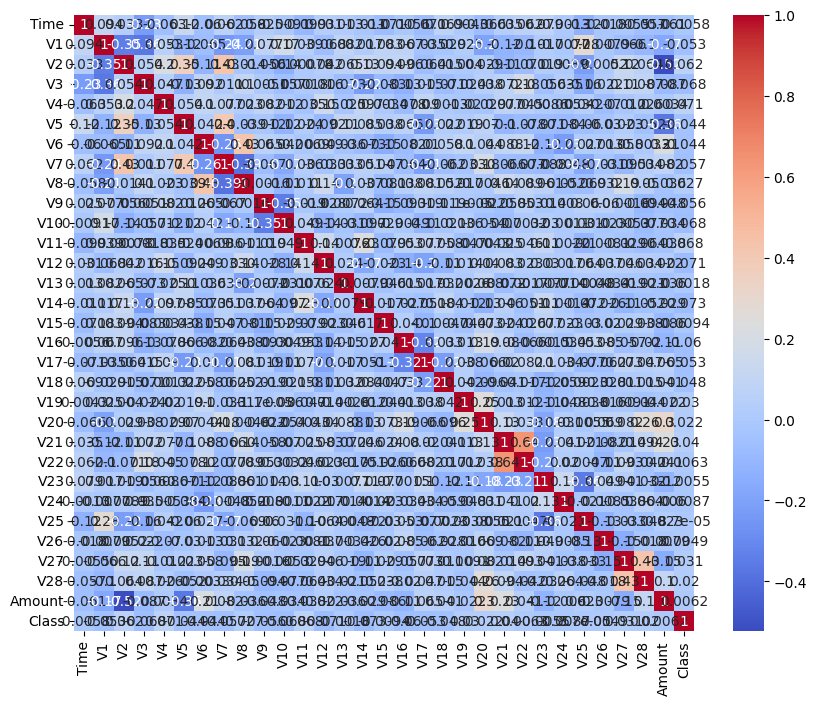

In [ ]:
#EDA
df_corr=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(df_corr,annot=True,cmap="coolwarm")
plt.show()

In [ ]:
#outlier removal
def Outlier(df,column):
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  return df[(df[column]>=lower)&(df[column]<=upper)]
num_cols = df.columns # Define num_cols to iterate over all columns
for col in num_cols:
  df=Outlier(df,col)

In [ ]:
x=df.drop("Class",axis=1)
y=df["Class"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
#feature scaling
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [ ]:
#model training
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)


RandomForestClassifier(random_state=42)

In [ ]:
#predictions
pred=model.predict(x_test)
#model exaluation
print(accuracy_score(y_test,pred))
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

1.0
[[31345]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31345

    accuracy                           1.00     31345
   macro avg       1.00      1.00      1.00     31345
weighted avg       1.00      1.00      1.00     31345



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
#save model
import pickle
with open("Random_Forest_Model.pkl","wb")as file:
  pickle.dump(model,file)